# **STDP Simulation of Acetaminophen (APAP) Hepatotoxicity Effects on the Brain**

The purpose of this project is to model how APAP hepatotoxicity affects brain plasticity using Spike-Timing Dependent Plasticity (STDP) and spiking neuron models.

## Introduction


* **Metabolic detoxification**: breaking down drugs, foreign molecules, and hormones to reduce their toxicity or biological activity (Ozougwu, 2017)

    * protects the body from harmful substances and helps maintain internal homeostasis

    * carried out by enzymes in hepatocytes (liver cells) in two phases

        * Phase I: enzymes make fat-soluble toxins more water-soluble by adding hydroxyl groups
        * Phase II: enzymes attach larger water-soluble groups to help flush them out of the body

    * exposure to harmful substances can overwhelm this process



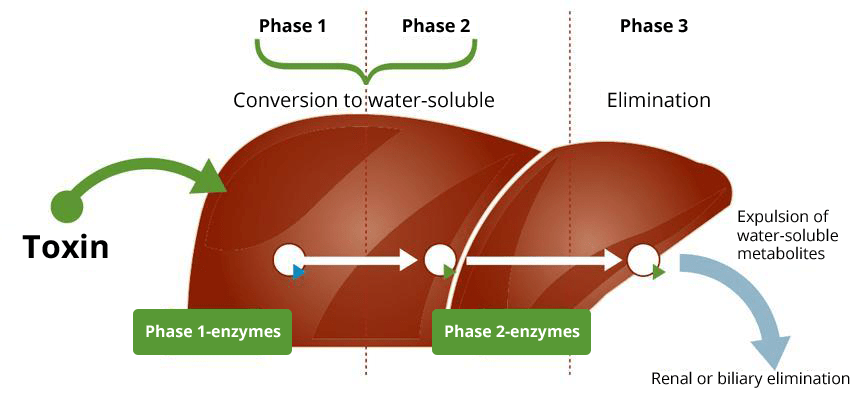

> **Image Source**: PiLeJe Laboratoire, n.d.

* **Drug-Induced Liver Injury (DILI)**

    * **Acetaminophen (APAP)**: most popular pain-relieving and fever-reducing over-the-counter medication in the U.S. (ex. Tylenol)

        * taken by more than 60 million Americans every week (Jaeschke & Ramachandran, 2024; Liao et al., 2023)

        * the leading cause of acute liver failure (ALF) -> approximately 250 deaths annually (Agrawal & Khazaeni, 2023)

    * APAP overdose overwhelms the detox pathways, leading to the buildup of a toxic metabolite called N-acetyl-p-benzoquinone imine (**NAPQI**) (Jaeschke & Ramachandran, 2024)
        
        * causes liver cells to die out -> liver fails to clear out toxins, such as **ammonia** from the blood

            * can pass through the blood-brain barrier


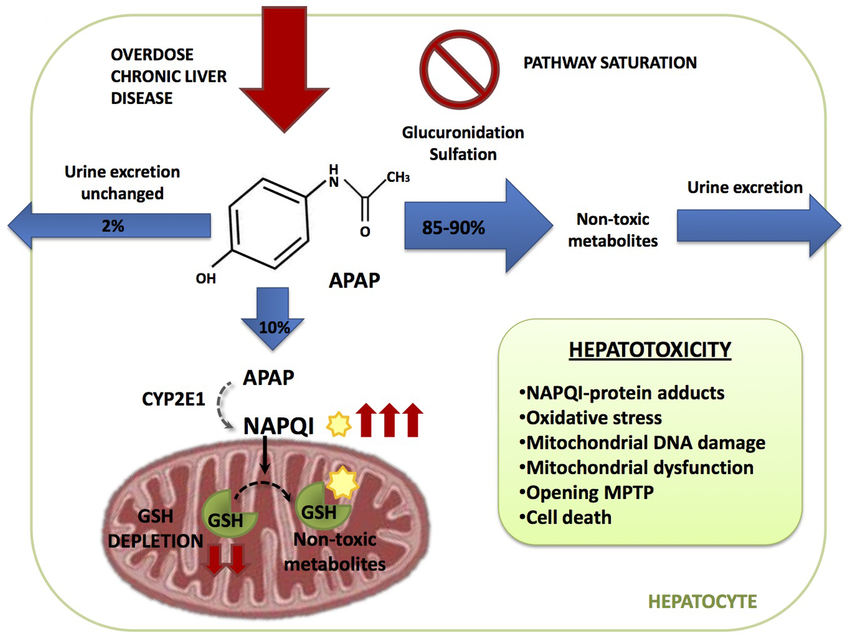

> **Image Source**: Moles et al. (2018)

* **Hepatic encephalopathy (HE)**: impaired brain function as a result of liver disease (Ferenci, 2017; Oja et al., 2017)

    * **Hyperammonemia** (increased accumulation of ammonia) is the primary factor (Oja et al., 2017)

        * disrupts the blood-brain barrier, letting other harmful substances in (Oja et al., 2017)

        * "causes *depression of synaptic transmission*" (Oja et al., 2017)

    * regarded as a "secondary factor" of ALF (Ghanem et al., 2016)

    * causes brain edema (swelling), which raises pressure inside the skull (Ghanem et al., 2016)
    
    * leads to cerebral herniation, when the pressure is too high (Ghanem et al., 2016)

    * has low survival rates and high risk of recurrence if underlying liver diease is not treated (Ferenci, 2017)




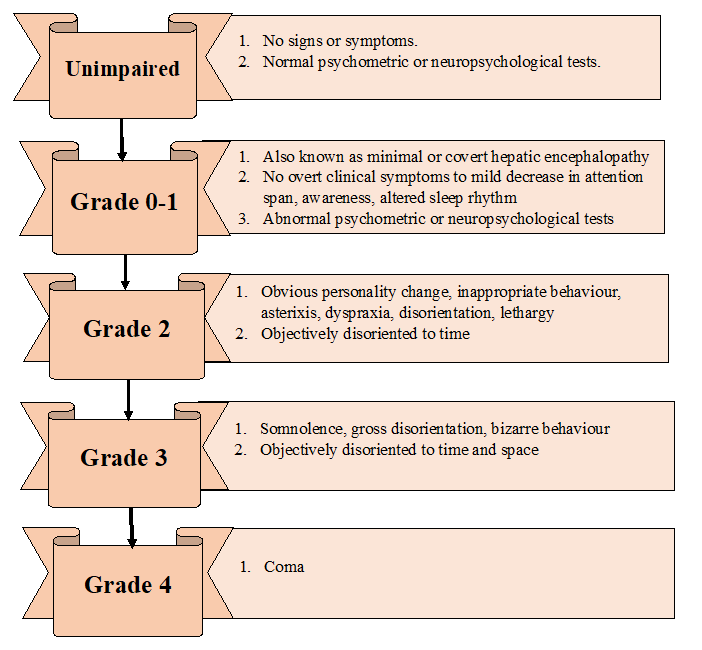

> **Image Source**: Ansari et al., 2020

## Install and Import the Necessary Libraries

In [ ]:
!pip install brian2

In [ ]:
# Neural simulation framework
from brian2 import *

# Visualization library
import matplotlib.pyplot as plt

## Set up an Simple STDP-based Neuron Model


In [ ]:
def run_traditional_network():

    start_scope()  # Reset all Brian2 objects
    seed(42)  # Set reproducible random seed

    # --- Neuron membrane parameters---

    tau = 10*ms             # Membrane time constant
    v_rest = -70*mV         # Resting membrane potential
    v_reset = -70*mV        # Reset potential after a spike
    v_threshold = -60*mV    # Voltage potential after firing a spike

    # --- STDP parameters ---

    tau_pre = 20*ms         # Time constant for pre-synaptic trace decay
    tau_post = 20*ms        # Time constant for post-synaptic trace decay
    A_pre = 0.01            # Amplitude for synaptic potentiation (pre-before-post spikes)

    # Amplitude for synaptic depression (post-before-pre spikes)
    A_post = -A_pre * tau_pre / tau_post * 1.05

    # Neuron model based on leaky integrate-and-fire (LIF) equation
    #  "unless refractory" -> no updates are made during the neuron's refractory period
    eqs = '''
    dv/dt = (v_rest - v) / tau : volt (unless refractory)
    '''

    # Input neuron group
    G_input = NeuronGroup(1, eqs, threshold='v>v_threshold', reset='v = v_reset', method='exact', refractory=5*ms)
    G_input.v = v_rest

    # Traditional STDP neuron group
    G_trad = NeuronGroup(1, eqs, threshold='v>v_threshold', reset='v = v_reset', method='exact', refractory=5*ms)
    G_trad.v = v_rest

    # Traditional STDP synapse (input -> traditional STDP neuron)
    syn_trad = Synapses(G_input, G_trad,
        '''
        w : 1
        dpre/dt = -pre / tau_pre : 1 (event-driven)
        dpost/dt = -post / tau_post : 1 (event-driven)
        ''',
        on_pre='''
        v_post += 15 * w * mV
        pre += A_pre
        w = clip(w + post, 0, 1)
        ''',
        on_post='''
        post += A_post
        w = clip(w + pre, 0, 1)
        ''',
        method='exact'
    )
    syn_trad.connect(i=0, j=0)
    syn_trad.w = 0.5

    # External Poisson input to G_input
    P = PoissonGroup(1, rates=100*Hz)                               # Create 1 Poisson neuron firing at 100 Hz
    input_syn = Synapses(P, G_input, on_pre='v_post += 20*mV')      # Connect Poisson input to G_input
    input_syn.connect()

    # Monitors to record synaptic weight changes
    M_trad = StateMonitor(syn_trad, 'w', record=True)

    # Spike monitors to record spiking activity
    spikemon_input = SpikeMonitor(G_input)          # Monitor spikes in the input neuron
    spikemon_trad = SpikeMonitor(G_trad)            # Monitor spikes in the traditional STDP neuron

    # Create and run custom network
    trad_net = Network(collect())  # Automatically collects all Brian2 objects
    trad_net.run(500*ms)

    return M_trad, spikemon_input, spikemon_trad

## Set up an APAP Toxicity STDP-based Neuron Model

In [ ]:
# Toxicity modifies weight change over time and synaptic potentiation

def run_toxic_network():

    start_scope()  # Reset all Brian2 objects
    seed(42)  # Set reproducible random seed

    # --- Neuron membrane parameters---

    tau = 10*ms             # Membrane time constant
    v_rest = -70*mV         # Resting membrane potential
    v_reset = -70*mV        # Reset potential after a spike
    v_threshold = -60*mV    # Voltage potential after firing a spike

    # --- STDP parameters ---

    tau_pre = 20*ms         # Time constant for pre-synaptic trace decay
    tau_post = 20*ms        # Time constant for post-synaptic trace decay
    A_pre = 0.005          # Reduced amplitude for synaptic potentiation (pre-before-post spikes)

    # Amplitude for synaptic depression (post-before-pre spikes)
    A_post = -A_pre * tau_pre / tau_post * 1.05

    # Neuron model based on leaky integrate-and-fire (LIF) equation
    #  "unless refractory" -> no updates are made during the neuron's refractory period
    eqs = '''
    dv/dt = (v_rest - v) / tau : volt (unless refractory)
    '''

    # Input neuron group
    G_input = NeuronGroup(1, eqs, threshold='v>v_threshold', reset='v = v_reset', method='exact', refractory=5*ms)
    G_input.v = v_rest

    # Traditional STDP neuron group
    G_toxic = NeuronGroup(1, eqs, threshold='v>v_threshold', reset='v = v_reset', method='exact', refractory=5*ms)
    G_toxic.v = v_rest

    # Traditional STDP synapse (input -> toxic STDP neuron)

    syn_toxic = Synapses(G_input, G_toxic,
        '''
        w : 1
        dpre/dt = -pre / tau_pre : 1 (event-driven)
        dpost/dt = -post / tau_post : 1 (event-driven)
        ''',
        on_pre=f'''
        v_post += 15 * w * mV
        pre += A_pre  # Reduced plasticity due to toxicity
        w = clip(w + post, 0, 0.5)  # Lowered max weight
        ''',
        on_post=f'''
        post += A_post  # Reduced depression amplitude due to toxicity
        w = clip(w + pre, 0, 0.5)  # Lowered max weight
        ''',
        method='exact'
    )
    syn_toxic.connect(i=0, j=0)
    syn_toxic.w = 0.5

    # External Poisson input
    P = PoissonGroup(1, rates=100*Hz)
    input_syn = Synapses(P, G_input, on_pre='v_post += 20*mV')
    input_syn.connect()

    # Monitors
    M_toxic = StateMonitor(syn_toxic, 'w', record=True)
    spikemon_input = SpikeMonitor(G_input)
    spikemon_toxic = SpikeMonitor(G_toxic)

    # Create and run custom network
    toxic_net = Network(collect())  # Automatically collects all Brian2 objects
    toxic_net.run(500*ms)

    return M_toxic, spikemon_toxic

## Result Comparisons

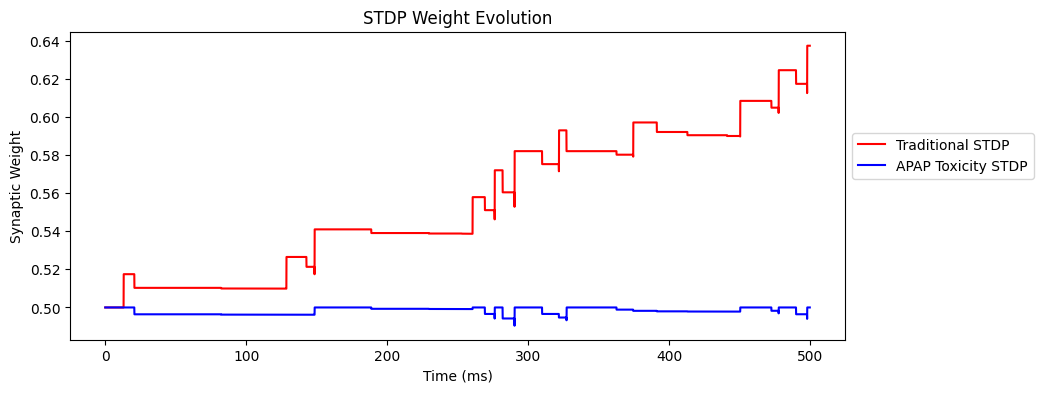

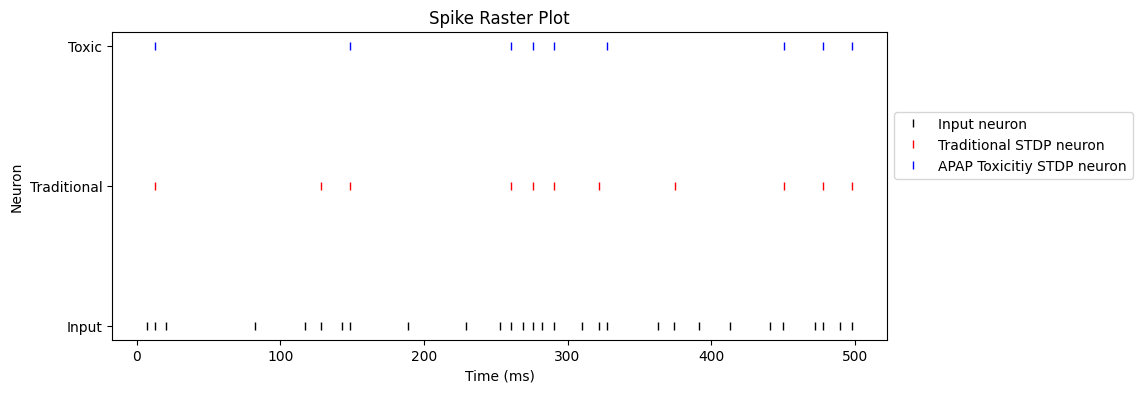

In [ ]:
M_trad, spikemon_input, spikemon_trad = run_traditional_network()
M_toxic, spikemon_toxic = run_toxic_network()

# Weight plot
plt.figure(figsize=(10, 4))
plt.plot(M_trad.t/ms, M_trad.w[0], label='Traditional STDP', color='red')
plt.plot(M_toxic.t/ms, M_toxic.w[0], label='APAP Toxicity STDP', color='blue')
plt.xlabel('Time (ms)')
plt.ylabel('Synaptic Weight')
plt.title('STDP Weight Evolution')
plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
plt.show()

# --- Spike raster plot ---
plt.figure(figsize=(10, 4))

# Plot input spikes
plt.plot(spikemon_input.t/ms, spikemon_input.i + 0, '|', color='black', label='Input neuron')

# Plot traditional STDP neuron spikes
plt.plot(spikemon_trad.t/ms, spikemon_trad.i + 2, '|', color = 'red', label='Traditional STDP neuron')

plt.plot(spikemon_toxic.t/ms, spikemon_toxic.i + 4, '|', color='blue', label='APAP Toxicitiy STDP neuron')

plt.yticks([0, 2, 4], ['Input', 'Traditional', 'Toxic'])
plt.xlabel('Time (ms)')
plt.ylabel('Neuron')
plt.title('Spike Raster Plot')
plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
plt.show()

*  The STDP weight evolution graph shows us the synaptic strength over time

* Traditional STDP (the red line) steadily increases in a staircase-like pattern from an initial weight of 0.50 to 0.64, indicating that the synapse is strengthening over time.

    * This reflects healthy plasticity that causes potentiation.

* APAP Toxicity STDP (blue line) starts at 0.50 but remains mostly flat, occasionally dipping before returning to the original level.

    * This suggests that under APAP toxicity, the synapse fails to strengthen properly, showing impaired plasticity, as correctly simulating the cognitive impairment that occurs due to HE.








In [ ]:
# Show spikes
print(f"Input neuron spikes: {sum(spikemon_input.i == 0)} times")
print(f"Traditional STDP neuron spikes: {sum(spikemon_trad.i == 0)} times")
print(f"APAP Toxicitiy STDP neuron spikes: {sum(spikemon_toxic.i == 0)} times")

Input neuron spikes: 29 times
Traditional STDP neuron spikes: 11 times
APAP Toxicitiy STDP neuron spikes: 9 times


* In the spike raster plot, we can see that the input neuron spiked 29 times, the normal STDP output neuron spiked 11 times, while the APAP toxicity one only spiked 9 times.

* This further demonstrates the disruptive effect of APAP on synaptic transmission because weaker synaptic weights lead to lower excitability in the post-synaptic neuron.

## Conclusion

* Under normal (traditional) STDP, synaptic strength increased over time and the post-synaptic neuron fired more frequently, indicating healthy synaptic plasticity.

* Under APAP toxicity conditions, synaptic weights barely changed and the output neuron fired less often, showing a clear disruption in plasticity

## References

* Agrawal, S., & Khazaeni, B. (2023). Acetaminophen Toxicity. In StatPearls [Internet]. StatPearls Publishing. https://www.ncbi.nlm.nih.gov/books/NBK441917/

* Ansari, A. J., Fatima, N., & Monawwar, M. Evaluation of Some of the Antibiotics in the Management of Hepatic Encephalopathy (HE): An Overview.

* Ferenci, P. (2017). Hepatic encephalopathy. Gastroenterology report, 5(2), 138-147.

* Ghanem, C. I., Pérez, M. J., Manautou, J. E., & Mottino, A. D. (2016). Acetaminophen from liver to brain: New insights into drug pharmacological action and toxicity. Pharmacological research, 109, 119-131.

* Jaeschke, H., & Ramachandran, A. (2024). Acetaminophen Hepatotoxicity: Paradigm for Understanding Mechanisms of Drug-Induced Liver Injury | Annual Reviews. https://www.annualreviews.org/content/journals/10.1146/annurev-pathmechdis-051122-094016

* Liao, J., Lu, Q., Li, Z., Li, J., Zhao, Q., & Li, J. (2023). Acetaminophen-induced liver injury: Molecular mechanism and treatments from natural products. Frontiers in Pharmacology, 14. https://doi.org/10.3389/fphar.2023.1122632

* Moles, A., Torres, S., Baulies, A., Garcia-Ruiz, C., & Fernandez-Checa, J. C. (2018). Mitochondrial-lysosomal axis in acetaminophen hepatotoxicity. Frontiers in Pharmacology, 9, 453.

* Ozougwu, J. C. (2017). Physiology of the liver. International Journal of Research in Pharmacy and Biosciences. https://www.academia.edu/38598619/Physiology_of_the_liver

* PiLeJe Laboratoire. (n.d.). Detoxification: A “How to” guide. PiLeJe. Retrieved May 7, 2025, from https://www.pileje.com/health-information/detoxification-a-how-to-guide

